In [2]:
import pandas as pd

In [3]:
calendar_df = pd.read_csv("../data/calendar.csv")
sales_df = pd.read_csv("../data/sales_train_evaluation.csv")
sell_prices_df = pd.read_csv("../data/sell_prices.csv")

In [4]:
sales_df.columns[:10], sales_df.columns[-10:]

(Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
        'd_2', 'd_3', 'd_4'],
       dtype='object'),
 Index(['d_1932', 'd_1933', 'd_1934', 'd_1935', 'd_1936', 'd_1937', 'd_1938',
        'd_1939', 'd_1940', 'd_1941'],
       dtype='object'))

In [5]:
# number of stores
print(f"Number of stores: {sales_df['store_id'].nunique()}")
print(f"Number of stores in each state: {sales_df.groupby('state_id')['store_id'].nunique()}")


Number of stores: 10
Number of stores in each state: state_id
CA    4
TX    3
WI    3
Name: store_id, dtype: int64


In [6]:
# how many cats in each store
print(f"Number of categories in each store: {sales_df.groupby('store_id')['cat_id'].nunique()}")
# all stores have 3 categories.

Number of categories in each store: store_id
CA_1    3
CA_2    3
CA_3    3
CA_4    3
TX_1    3
TX_2    3
TX_3    3
WI_1    3
WI_2    3
WI_3    3
Name: cat_id, dtype: int64


In [7]:
# how many items in each store-category
print(f"Number of items in each store-category: {sales_df.groupby(['store_id', 'cat_id'])['item_id'].nunique()}")
# all store-category combinations have 50 items. So, we have 10 stores,

Number of items in each store-category: store_id  cat_id   
CA_1      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
CA_2      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
CA_3      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
CA_4      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
TX_1      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
TX_2      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
TX_3      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
WI_1      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
WI_2      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
WI_3      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
Name: item_id, dtype: int64


In [8]:
print("Number of unique items:", sales_df['item_id'].nunique())

Number of unique items: 3049


In [9]:
3049 * 10

30490

There are 10 stores in 3 states of CA (4), TX (3), WI (3). 
Each store carries 3 categories - FOODS (1437), HOBBIES (565), HOUSEHOLD (1047) with a total of 3049 SKUs

This makes a total of 30490 store-item combinations.

In [10]:
# Now let's check what is in calendar
calendar_df.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [11]:
calendar_df['d'].nunique()

1969

In [16]:
calendar_df[['event_name_1', 'event_type_1']].drop_duplicates().head()

,event_name_1,event_type_1
0,NaN,NaN
8,SuperBowl,Sporting
16,ValentinesDay,Cultural
23,PresidentsDay,National
39,LentStart,Religious


In [17]:
calendar_df['event_type_1'].unique(), calendar_df['event_type_2'].unique()

(array([nan, 'Sporting', 'Cultural', 'National', 'Religious'], dtype=object),
 array([nan, 'Cultural', 'Religious'], dtype=object))

In [19]:
calendar_df['snap_CA'].value_counts()

snap_CA
0    1319
1     650
Name: count, dtype: int64

In [21]:
sell_prices_df.shape

(6841121, 4)

In [27]:
sell_prices_df.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [26]:
sales_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


<Axes: >

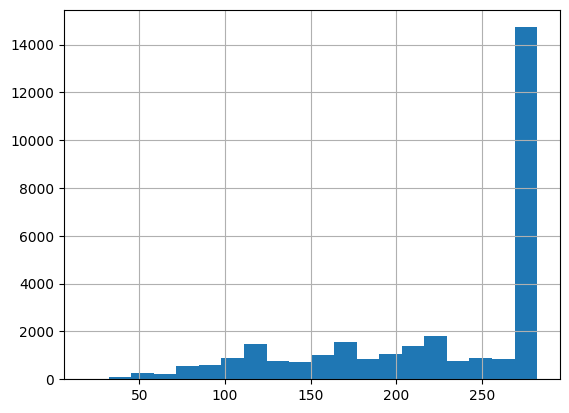

In [29]:
# sell prices are on weekly basis, how frequently do prices change for each item-store combination, pllot
sell_prices_df.groupby(['item_id', 'store_id'])['wm_yr_wk'].nunique().hist(bins=20)

In [24]:
# convert the sales_df from wide to long format
sales_long_df = sales_df.melt(
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    var_name='d',
    value_name='sales'
)

sales_long_df = sales_long_df.merge(calendar_df, on='d', how='left')

sales_long_df = sales_long_df.merge(sell_prices_df, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

sales_long_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN


In [31]:
# let's learn about how prices change over time.

sell_prices_df.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


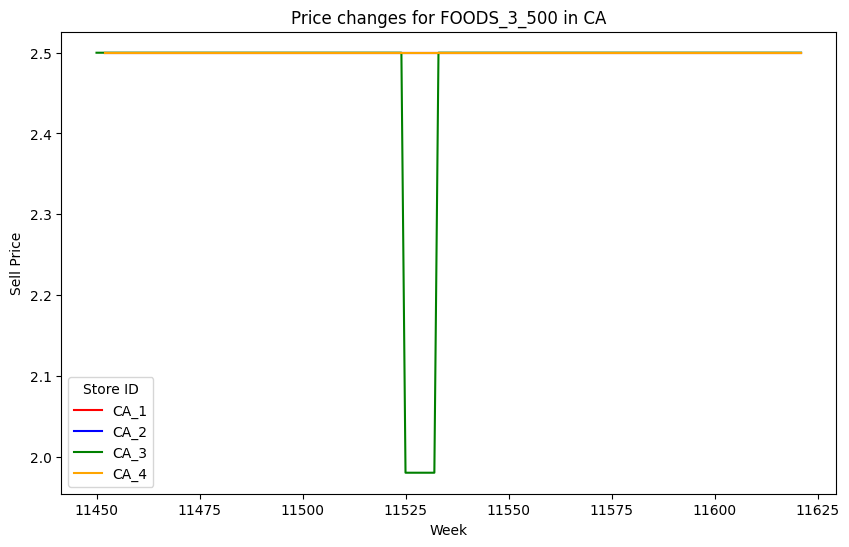

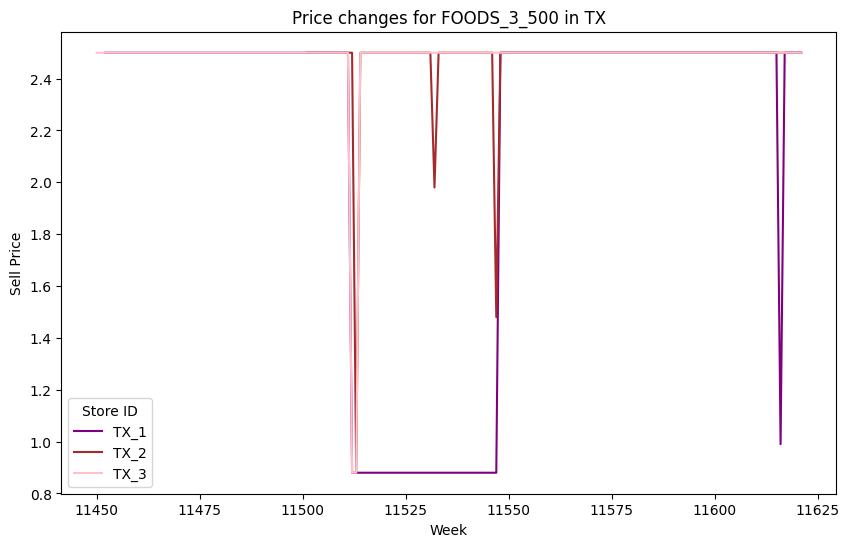

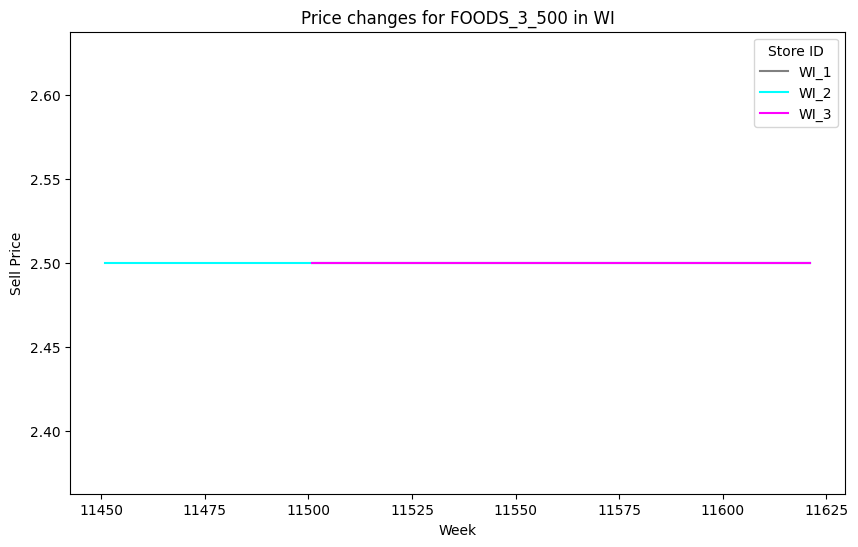

In [55]:
# plot sell_prices_df for a random store_id, item_id combination
# inspect if same item has different prices in different stores
import matplotlib.pyplot as plt
random_item_id = sell_prices_df['item_id'].sample(1).values[0]
# map colors to store_id
color_map = {store_id: color for store_id, color in zip(sell_prices_df['store_id'].unique(), 
                                                        ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan', 'magenta'])}

filtered = sell_prices_df[(sell_prices_df['item_id'] == random_item_id)]\
    .sort_values('wm_yr_wk')


states = sales_long_df['state_id'].unique()

for state in states:
    fig, ax = plt.subplots(figsize=(10, 6))
    for store_id, group in filtered[filtered['store_id'].str.startswith(state)]\
        .groupby('store_id'):
        ax.plot(group['wm_yr_wk'], group['sell_price'], label=store_id, color=color_map[store_id])
    ax.set_xlabel('Week')
    ax.set_ylabel('Sell Price')
    ax.legend(title='Store ID')
    plt.title(f"Price changes for {random_item_id} in {state}")
    plt.show()

### Price does not seem to remain fixed or follow the same change pattern across different stores. 

## How frequently do prices change?
A constant price won't be of any value

In [67]:
# flag each week where price changed from prior week
sp = sell_prices_df.copy()
sp['price_changed'] = sp.groupby(['store_id', 'item_id'])['sell_price']\
    .diff().fillna(0).ne(0)
# first row of each group is always NaN → treat as no change
sp['price_changed'] = sp['price_changed'].fillna(False)

# changes per item-store pair
change_counts = sp.groupby(['store_id', 'item_id'])['price_changed'].sum()
print(change_counts.describe())
print(change_counts.value_counts().head(20))  # how many pairs changed 0x, 1x, 2x...

count    30490.000000
mean         2.584946
std          3.377369
min          0.000000
25%          0.000000
50%          2.000000
75%          3.000000
max         50.000000
Name: price_changed, dtype: float64
price_changed
0     8247
1     6347
2     5313
3     3213
4     2152
5     1370
6      862
7      673
8      518
9      440
10     328
11     251
12     160
13     139
15      93
14      72
16      55
19      34
17      33
18      32
Name: count, dtype: int64


## Are there any fixed price items
Yes - 8247 store-item pairs with no price change ever

In [69]:
change_counts[change_counts == 0]

store_id  item_id        
CA_1      FOODS_1_014        0
          FOODS_1_021        0
          FOODS_1_039        0
          FOODS_1_042        0
          FOODS_1_048        0
                            ..
WI_3      HOUSEHOLD_2_505    0
          HOUSEHOLD_2_512    0
          HOUSEHOLD_2_513    0
          HOUSEHOLD_2_515    0
          HOUSEHOLD_2_516    0
Name: price_changed, Length: 8247, dtype: int64

In [68]:
# filter change_counts series with item id FOODS_3_500
change_counts[change_counts.index.get_level_values('item_id') == 'FOODS_3_500']

store_id  item_id    
CA_1      FOODS_3_500    0
CA_2      FOODS_3_500    0
CA_3      FOODS_3_500    2
CA_4      FOODS_3_500    0
TX_1      FOODS_3_500    4
TX_2      FOODS_3_500    6
TX_3      FOODS_3_500    2
WI_1      FOODS_3_500    0
WI_2      FOODS_3_500    0
WI_3      FOODS_3_500    0
Name: price_changed, dtype: int64

<Axes: >

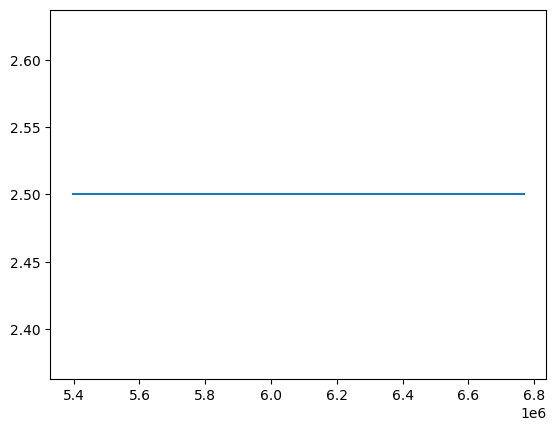

In [66]:
sp[(sp['item_id'] == 'FOODS_3_500') 
   & (sp['store_id'].str.startswith('WI'))]['sell_price'].plot()

In [47]:
# are there any fixed price items?
change_counts[change_counts == 0]

Series([], Name: price_changed, dtype: int64)

In [49]:
sp.groupby(['store_id', 'item_id'])['price_changed']\
    .cumsum()

0          1
1          1
2          2
3          2
4          2
          ..
6841116    1
6841117    1
6841118    1
6841119    1
6841120    1
Name: price_changed, Length: 6841121, dtype: int64

In [ ]:
# how many consecutive weeks does the price remain unchanged for each item-store pair?
sp['unchanged_group'] = sp.groupby(['store_id', 'item_id'])['price_changed']\
    .cumsum()
unchanged_durations = sp.groupby(['store_id', 'item_id', 'unchanged_group']).size()
print(unchanged_durations.describe())

count    109305.000000
mean         62.587448
std          70.019538
min           1.000000
25%          10.000000
50%          34.000000
75%          95.000000
max         282.000000
dtype: float64
